# Softmax Regression — từ công thức toán đến code (4 giai đoạn) trên Diamonds

**Môn học:** Học máy nâng cao (ml_ad) · **Học viên:** Nguyễn Phương Anh Tú · **MSHV:** 2611328

> **Phương pháp của môn (áp dụng cho mọi thuật toán).** Notebook triển khai theo đúng 4 giai đoạn:
> 1. **Giải tay** — dẫn kiến thức toán từng bước, kiểm chứng bằng sai phân hữu hạn, trước khi viết mã.
> 2. **Bản thuần, KHÔNG thư viện** — cài từ công thức bằng NumPy.
> 3. **Bản thư viện** — `scikit-learn`.
> 4. **Bản framework** — `PyTorch` (sau cùng, cùng learning rate/epochs với bản thuần).

**Bộ dữ liệu:** [`diamonds`](https://www.kaggle.com/datasets/shivam2503/diamonds) (Kaggle/seaborn, **thực tế**, 53 940 viên kim cương). Bộ dữ liệu có **đúng 2 cột nhãn** dùng xuyên suốt 3 notebook của bài tập này:

- **`price`** (giá bán, USD) — nhãn **LIÊN TỤC** → dùng cho *Linear Regression*.
- **`cut`** (chất lượng cắt, 5 mức: Fair < Good < Very Good < Premium < Ideal) — nhãn **RỜI RẠC** → dùng **nguyên 5 lớp** cho **Softmax Regression** (notebook này), hoặc **nhị phân hoá** "Ideal vs không" cho *Logistic Regression*.

**8 đặc trưng dùng chung** cho cả 3 notebook: `carat, depth, table, x, y, z, color_ord, clarity_ord` (`color`, `clarity` đã mã hoá thứ bậc theo đúng thứ tự chất lượng thực tế của kim cương). Vì `carat` và `x, y, z` (kích thước vật lý) tương quan rất cao với nhau (đa cộng tuyến vừa phải — số điều kiện của ma trận đặc trưng đã chuẩn hoá ước lượng ≈ 624), gradient descent **cần nhiều epoch hơn bình thường** để hội tụ khớp nghiệm của thư viện — đây là điểm sẽ được nêu **trung thực**, không giấu, ở phần bản thuần bên dưới.

**Bài toán của notebook này:** dự đoán **toàn bộ 5 lớp** của `cut` (0=Fair … 4=Ideal) từ 8 đặc trưng — bài toán phân loại đa lớp ($K=5$) kinh điển; softmax regression là mô hình tuyến tính tiêu chuẩn. Đây cũng là bước chuẩn bị: notebook multi-task (làm riêng) sẽ dùng lại đúng nhánh đầu ra 5 lớp này trong một mạng thân chung.

## 0. Nạp dữ liệu diamonds và tiền xử lý (CHUNG với 2 notebook kia)

Khối tiền xử lý dưới đây **giống hệt byte-by-byte** ở cả 3 notebook (Linear/Logistic/Softmax) để tập train/test, chuẩn hoá và các cột đặc trưng khớp nhau tuyệt đối — điều kiện bắt buộc để notebook multi-task sau này gộp lại được.

In [1]:
%matplotlib inline
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110

# --- KHOI TIEN XU LY CHUAN (giong het 3 notebook) ---
_cands = ["data/diamonds.csv", "../data/diamonds.csv",
          "/home/alexdev/Projects/learning-master-ute/ml_ad/b8/data/diamonds.csv"]
CSV = next((p for p in _cands if os.path.exists(p)), _cands[0])
df = pd.read_csv(CSV)
df = df[(df.x > 0) & (df.y > 0) & (df.z > 0)].reset_index(drop=True)  # drop 20 dong loi (x/y/z=0)

color_order = {c: i for i, c in enumerate(["J", "I", "H", "G", "F", "E", "D"])}       # J te nhat -> D tot nhat
clarity_order = {c: i for i, c in enumerate(["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"])}  # I1 te nhat -> IF tot nhat
cut_order = {c: i for i, c in enumerate(["Fair", "Good", "Very Good", "Premium", "Ideal"])}
df["color_ord"] = df["color"].map(color_order)
df["clarity_ord"] = df["clarity"].map(clarity_order)
df["cut_ord"] = df["cut"].map(cut_order)

FEAT_COLS = ["carat", "depth", "table", "x", "y", "z", "color_ord", "clarity_ord"]  # 8 dac trung dung chung
X = df[FEAT_COLS].values.astype(float)
y_price = df["price"].values.astype(float)          # nhan LIEN TUC (dung o notebook Linear)
y_bin = (df["cut"] == "Ideal").astype(int).values    # nhan ROI RAC nhi phan (dung o notebook Logistic)
y_multi = df["cut_ord"].values                       # nhan ROI RAC 5 lop -> DUNG O NOTEBOOK NAY

Xtr, Xte, ptr, pte, btr, bte, mtr, mte = train_test_split(
    X, y_price, y_bin, y_multi, test_size=0.2, random_state=1, stratify=y_multi
)
mu, sd = Xtr.mean(axis=0), Xtr.std(axis=0)
Xtr_s, Xte_s = (Xtr - mu) / sd, (Xte - mu) / sd

CLS_NAMES = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
K = len(CLS_NAMES)
print("So dac trung:", X.shape[1], "| so lop cut:", K, "| tong so mau (sau loc):", len(df))
print("Kich thuoc train/test:", Xtr_s.shape, Xte_s.shape)
print("Phan bo lop TOAN BO du lieu:", dict(zip(CLS_NAMES, np.bincount(y_multi))))
print("Phan bo lop TRAIN:", dict(zip(CLS_NAMES, np.bincount(mtr))))
print("Phan bo lop TEST: ", dict(zip(CLS_NAMES, np.bincount(mte))))
print("Trung binh train (sau chuan hoa) ~", Xtr_s.mean(0).round(3))

So dac trung: 8 | so lop cut: 5 | tong so mau (sau loc): 53920
Kich thuoc train/test: (43136, 8) (10784, 8)
Phan bo lop TOAN BO du lieu: {'Fair': np.int64(1609), 'Good': np.int64(4902), 'Very Good': np.int64(12081), 'Premium': np.int64(13780), 'Ideal': np.int64(21548)}
Phan bo lop TRAIN: {'Fair': np.int64(1287), 'Good': np.int64(3922), 'Very Good': np.int64(9665), 'Premium': np.int64(11024), 'Ideal': np.int64(17238)}
Phan bo lop TEST:  {'Fair': np.int64(322), 'Good': np.int64(980), 'Very Good': np.int64(2416), 'Premium': np.int64(2756), 'Ideal': np.int64(4310)}
Trung binh train (sau chuan hoa) ~ [ 0.  0.  0.  0.  0. -0.  0. -0.]


### 0bis. Phân bố lớp — vì sao cần F1-macro, không chỉ accuracy

`cut` **lệch rõ rệt**: Ideal (~21 500 mẫu, 40%) và Premium (~13 800, 26%) áp đảo, trong khi Fair chỉ ~1 600 mẫu (3%). Với dữ liệu lệch, **accuracy dễ đánh lừa** — một mô hình "lười" chỉ đoán Ideal cho tất cả đã đạt gần 40% mà không học được gì. Thước đo chính xác hơn là **F1-macro** (trung bình cộng F1 của 5 lớp, mỗi lớp trọng số bằng nhau bất kể số mẫu) — notebook này báo cáo **cả hai**, nhưng ưu tiên F1-macro khi so sánh mô hình.

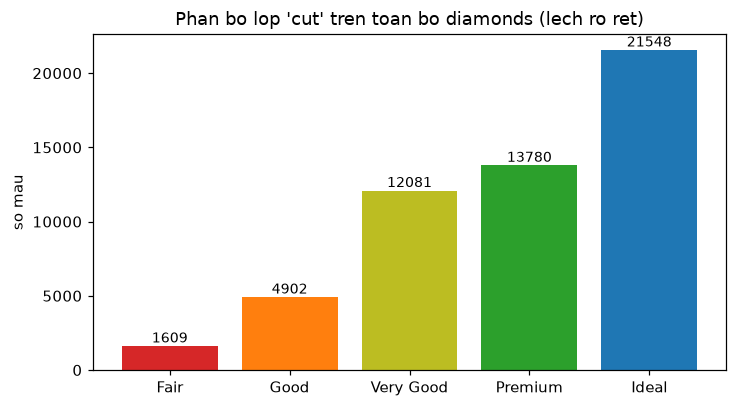

In [2]:
counts_all = np.bincount(y_multi)
fig, ax = plt.subplots(figsize=(6.8, 3.8))
colors5 = ["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#1f77b4"]
bars = ax.bar(CLS_NAMES, counts_all, color=colors5)
for b, v in zip(bars, counts_all):
    ax.text(b.get_x() + b.get_width()/2, v + 250, str(v), ha="center", fontsize=9)
ax.set_ylabel("so mau"); ax.set_title("Phan bo lop 'cut' tren toan bo diamonds (lech ro ret)")
fig.tight_layout(); plt.show()

## 1. Mô hình và hàm mất mát

Với 2 lớp, hồi quy logistic dùng sigmoid $\sigma(z) \in (0,1)$ cho một xác suất. Với $K=5$ lớp `cut`, cần **một phân phối xác suất** trên 5 đầu ra (mỗi giá trị dương, tổng đúng bằng 1) — đó là hàm **softmax**, tổng quát hoá tự nhiên của sigmoid.

**Điểm số (logit).** Với đặc trưng $x \in \mathbb{R}^{8}$, trọng số $W \in \mathbb{R}^{8 \times 5}$ và thiên lệch $b \in \mathbb{R}^{5}$:
$$z = W^\top x + b \in \mathbb{R}^{5}.$$

**Softmax** biến điểm số thành xác suất:
$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{5} e^{z_j}}, \qquad \sum_k \hat{y}_k = 1.$$

**Mất mát entropy chéo** của một mẫu (nhãn one-hot $y$, lớp đúng $c$):
$$\ell = -\sum_{k=1}^{5} y_k \log \hat{y}_k = -\log \hat{y}_c.$$

Trên cả tập $N$ mẫu: $\mathcal{L} = -\tfrac{1}{N}\sum_i \log \hat{y}_{i,c_i}$.

## 2. GIẢI TAY — dẫn xuất gradient từng bước

Mục tiêu: tính $\partial \mathcal{L}/\partial W$ và $\partial \mathcal{L}/\partial b$.

**Bước 1. Đạo hàm theo logit.** Với $\hat{y}_k = e^{z_k}/\sum_j e^{z_j}$ và $\ell = -\sum_k y_k \log \hat{y}_k$, ta chứng minh được:
$$\frac{\partial \ell}{\partial z_m} = \hat{y}_m - y_m.$$
(Vì $\partial \log \hat{y}_k / \partial z_m = \mathbb{1}[k=m] - \hat{y}_m$; thay vào và dùng $\sum_k y_k = 1$.)

**Bước 2. Theo trọng số và thiên lệch.** Vì $z_m = W_{\cdot m}^\top x + b_m$:
$$\frac{\partial \ell}{\partial W_{jm}} = x_j(\hat{y}_m - y_m), \qquad \frac{\partial \ell}{\partial b_m} = \hat{y}_m - y_m.$$

**Bước 3. Gộp cả batch.** Đặt $P \in \mathbb{R}^{N\times 5}$ là ma trận xác suất, $Y \in \{0,1\}^{N\times 5}$ là one-hot:
$$\boxed{\;\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{N} X^\top (P - Y), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{N}\mathbf{1}^\top (P - Y)\;}$$

Gradient của logit chỉ là $(P - Y)$ — sai số dự đoán trừ nhãn — nên bản thuần chỉ cần hai phép nhân ma trận, không cần autograd. Mục 2bis thay số cụ thể; cell mã kiểm chứng công thức bằng **sai phân hữu hạn**.

### 2bis. Giải tay với số cụ thể (thay số vào công thức)

Lấy đúng viên kim cương **đầu tiên của tập train** (đã chuẩn hoá) để thay số từng bước.

**Bảng ý nghĩa từng kí hiệu** — đọc trước khi xem tính toán:

| Kí hiệu | Đọc là | Ý nghĩa | Kích thước | Giá trị ở mẫu này |
|---|---|---|---|---|
| `x` | "x" | 8 đặc trưng đã chuẩn hoá (carat, depth, table, x, y, z, color_ord, clarity_ord) | (8,) | `[-0.986, 0.1036, -0.6493, -1.17, -1.1552, -1.1336, 1.5241, -0.0316]` |
| `W` | "W" | ma trận trọng số — mỗi **cột** là trọng số của 1 lớp `cut` | (8, 5) | (cho ở dưới, tự chọn nhỏ để minh hoạ) |
| `b` | "b" | thiên lệch (bias) của 5 lớp | (5,) | `[0, 0.05, 0, -0.05, 0.02]` |
| `z = Wᵀx + b` | "z" | **điểm số thô** (logit) của 5 lớp Fair/Good/Very Good/Premium/Ideal | (5,) | `[0.0287, -0.1188, -0.0522, -0.1496, 0.0515]` |
| `p = softmax(z)` | "p" | **xác suất** 5 lớp (dương, tổng = 1) | (5,) | `[0.2153, 0.1858, 0.1986, 0.1801, 0.2203]` |
| `y` | "y" | nhãn thật dạng **one-hot** (lớp đúng = 1, còn lại 0) | (5,) | `[0, 0, 0, 0, 1]` (Ideal) |
| `ℓ = -Σ yₖ log pₖ` | "ell" | mất mát entropy chéo của mẫu này (càng nhỏ càng tốt) | số | `1.5130` |
| `∂ℓ/∂z = p - y` | "grad-z" | đạo hàm mất mát theo điểm số — cho *hướng* cần sửa | (5,) | `[0.2153, 0.1858, 0.1986, 0.1801, -0.7797]` |

**Nhãn thật của mẫu này:** viên kim cương đầu tiên có `cut = Ideal` (chỉ số lớp 4 trong `["Fair","Good","Very Good","Premium","Ideal"]`).

**Bước 1 — Điểm số `z = Wᵀx + b`** (mỗi lớp = tích vô hướng giữa `x` (8 số) và một cột của `W`, cộng thiên lệch). Ví dụ lớp 0 (Fair), cột đầu của `W` là `[0.10, 0.05, -0.02, 0.08, 0.03, -0.05, 0.12, 0.07]`:
- `z_Fair  = 0.10*(-0.986) + 0.05*0.1036 + (-0.02)*(-0.6493) + 0.08*(-1.17) + 0.03*(-1.1552) + (-0.05)*(-1.1336) + 0.12*1.5241 + 0.07*(-0.0316) + 0 = 0.0287`
- Làm tương tự cho 4 cột còn lại (Good, Very Good, Premium, Ideal) ra: `z = [0.0287, -0.1188, -0.0522, -0.1496, 0.0515]`.

**Bước 2 — Softmax** (trừ max trước khi lấy exp để chống tràn số). `max(z) = 0.0515`, nên `z' = z - 0.0515 = [-0.0228, -0.1703, -0.1037, -0.2011, 0]`:
- `exp(z') = [0.9775, 0.8434, 0.9015, 0.8178, 1.0000]`, tổng ≈ `4.5402`
- `p = exp(z') / 4.5402 = [0.2153, 0.1858, 0.1986, 0.1801, 0.2203]` → mô hình đoán **Ideal** (0.2203 cao nhất, sát nút vì `W` chọn nhỏ/ngẫu nhiên) → đúng bằng nhãn thật, nhưng các xác suất gần như đều nhau (mô hình chưa học gì).

**Bước 3 — Mất mát entropy chéo.** Nhãn thật lớp 4 (Ideal) ⇒ `y = [0,0,0,0,1]`. Entropy chéo **chỉ phạt lớp đúng**:
`ℓ = -log(p_Ideal) = -log(0.2203) = 1.5130`
Loss còn khá lớn (gần `-log(1/5) = 1.609` của đoán ngẫu nhiên đều) vì `W`, `b` minh hoạ chưa được huấn luyện.

**Bước 4 — Gradient** `∂ℓ/∂z = p - y` (công thức đã dẫn ở Mục 2):
`∂ℓ/∂z = [0.2153-0, 0.1858-0, 0.1986-0, 0.1801-0, 0.2203-1] = [0.2153, 0.1858, 0.1986, 0.1801, -0.7797]`
- **Dương** ở 4 lớp sai (Fair, Good, Very Good, Premium): gradient descent sẽ **giảm** các logit này.
- **Âm** ở lớp đúng (Ideal, -0.7797): gradient descent sẽ **tăng** logit này lên — đúng hướng.

Cell kế tiếp chạy đúng các con số trên bằng mã, đối chiếu gradient giải tích với sai phân hữu hạn, rồi vẽ thành sơ đồ.

In [3]:
# === Giai doan 1: GIAI TAY tren 1 mau (vien kim cuong dau tien cua tap train) ===
x0 = Xtr_s[0]                                    # 8 dac trung da chuan hoa
y0_idx = mtr[0]                                  # chi so lop that (0..4)
print("x0 =", x0)
print("Nhan that (cut) =", CLS_NAMES[y0_idx], " (chi so", y0_idx, ")")

W0 = np.array([
    [ 0.10, -0.05,  0.02,  0.08, -0.10],
    [ 0.05,  0.10, -0.05,  0.00,  0.03],
    [-0.02,  0.04,  0.06, -0.03,  0.01],
    [ 0.08, -0.02,  0.05,  0.10, -0.06],
    [ 0.03,  0.06, -0.04,  0.02,  0.05],
    [-0.05,  0.03,  0.02, -0.01,  0.04],
    [ 0.12, -0.08,  0.03,  0.06, -0.02],
    [ 0.07,  0.02, -0.03,  0.09,  0.01],
])                                                # (8,5) - tu chon nho de minh hoa
b0 = np.array([0.0, 0.05, 0.0, -0.05, 0.02])      # (5,)

z0 = W0.T @ x0 + b0
print("\nz (logit 5 lop) =", z0)
p0 = np.exp(z0 - z0.max()); p0 /= p0.sum()        # softmax ON DINH (tru max)
print("p (xac suat 5 lop) =", p0, " (tong = %.4f)" % p0.sum())

y0 = np.eye(K)[y0_idx]
loss0 = -np.sum(y0 * np.log(p0))
print("y (one-hot) =", y0)
print("loss (entropy cheo) = %.4f" % loss0)

grad_z0 = p0 - y0
print("dL/dz = p - y =", grad_z0)
print("dL/dW = x (p-y)^T, shape ->", np.outer(x0, grad_z0).shape)

# === Kiem chung gradient bang sai phan huu han tren ca batch train ===
def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)          # tru max: chong tran (overflow)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def loss_and_grad(W, b, X, Y):
    P = softmax(X @ W + b); n = len(X)
    L = -np.mean(np.sum(Y * np.log(P + 1e-12), axis=1))
    gW = X.T @ (P - Y) / n
    gb = (P - Y).mean(axis=0)
    return L, gW, gb

Y_tr = np.eye(K)[mtr]
rng = np.random.default_rng(0)
Wchk = rng.normal(size=(8, K)) * 0.1; bchk = np.zeros(K)
L, gW, gb = loss_and_grad(Wchk, bchk, Xtr_s, Y_tr)

eps = 1e-6
gW_num = np.zeros_like(Wchk)
for i in range(Wchk.shape[0]):
    for j in range(Wchk.shape[1]):
        Wp = Wchk.copy(); Wp[i, j] += eps
        Lp, _, _ = loss_and_grad(Wp, bchk, Xtr_s, Y_tr)
        Wm = Wchk.copy(); Wm[i, j] -= eps
        Lm, _, _ = loss_and_grad(Wm, bchk, Xtr_s, Y_tr)
        gW_num[i, j] = (Lp - Lm) / (2 * eps)
diff = np.abs(gW - gW_num).max()
print("\nKiem chung gradient (ca batch train): max|giai tich - sai phan| = %.2e" % diff)
print("=> cong thuc o Muc 2 DUNG" if diff < 1e-6 else "=> CONG THUC SAI, can xem lai")

x0 = [-0.986   0.1036 -0.6493 -1.17   -1.1552 -1.1336  1.5241 -0.0316]
Nhan that (cut) = Ideal  (chi so 4 )

z (logit 5 lop) = [ 0.0287 -0.1188 -0.0522 -0.1496  0.0515]
p (xac suat 5 lop) = [0.2153 0.1858 0.1986 0.1801 0.2203]  (tong = 1.0000)
y (one-hot) = [0. 0. 0. 0. 1.]
loss (entropy cheo) = 1.5130
dL/dz = p - y = [ 0.2153  0.1858  0.1986  0.1801 -0.7797]
dL/dW = x (p-y)^T, shape -> (8, 5)



Kiem chung gradient (ca batch train): max|giai tich - sai phan| = 3.55e-10
=> cong thuc o Muc 2 DUNG


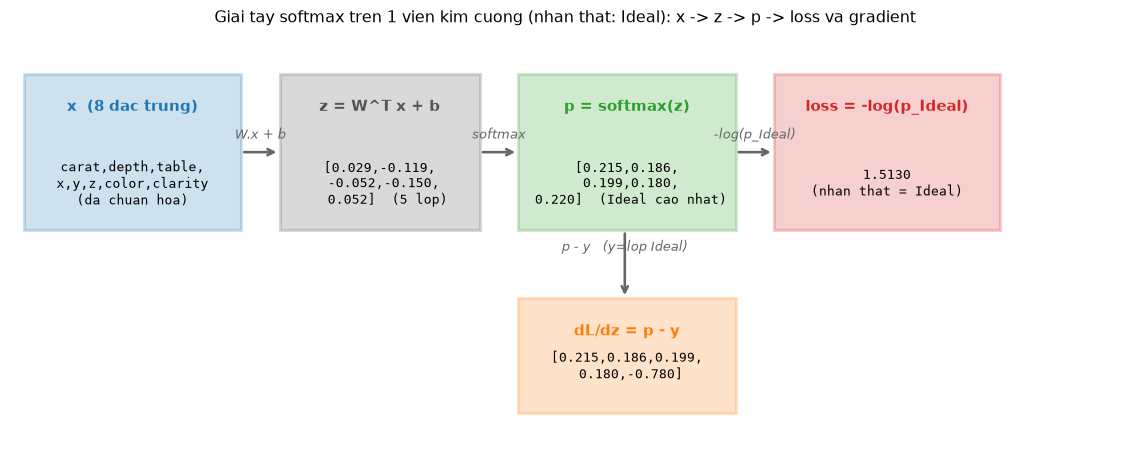

In [4]:
# === So do giai tay (anh nhung trong notebook de xem) ===
fig, ax = plt.subplots(figsize=(13, 4.8))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.8); ax.axis("off")

def box(x, y, w, h, title, body, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fill=True, facecolor=color,
                               alpha=0.22, edgecolor=color, lw=2))
    ax.text(x + w/2, y + h - 0.30, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color=color)
    ax.text(x + w/2, y + 0.55, body, ha="center", va="center",
            fontsize=8.3, family="monospace")

def arrow(x1, y1, x2, y2, label):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.7, color="#666"))
    ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.16, label, ha="center",
            fontsize=8.5, color="#666", style="italic")

ytop, h = 2.45, 1.85
box(0.15, ytop, 2.55, h, "x  (8 dac trung)", "carat,depth,table,\nx,y,z,color,clarity\n(da chuan hoa)", "#1f77b4")
box(3.15, ytop, 2.35, h, "z = W^T x + b", "[0.029,-0.119,\n -0.052,-0.150,\n  0.052]  (5 lop)", "#555555")
box(5.95, ytop, 2.55, h, "p = softmax(z)", "[0.215,0.186,\n 0.199,0.180,\n 0.220]  (Ideal cao nhat)", "#2ca02c")
box(8.95, ytop, 2.65, h, "loss = -log(p_Ideal)", "1.5130\n(nhan that = Ideal)", "#d62728")
arrow(2.70, ytop + h/2, 3.15, ytop + h/2, "W.x + b")
arrow(5.50, ytop + h/2, 5.95, ytop + h/2, "softmax")
arrow(8.50, ytop + h/2, 8.95, ytop + h/2, "-log(p_Ideal)")
# nhanh gradient (p - y) duoi p
box(5.95, 0.30, 2.55, 1.35, "dL/dz = p - y", "[0.215,0.186,0.199,\n 0.180,-0.780]", "#ff7f0e")
arrow(7.20, ytop, 7.20, 1.65, "p - y   (y=lop Ideal)")
ax.set_title("Giai tay softmax tren 1 vien kim cuong (nhan that: Ideal): x -> z -> p -> loss va gradient",
             fontsize=10.5, pad=6)
plt.show()

## 3. Giai đoạn 2 — BẢN THUẦN (NumPy duy nhất, không thư viện ML)

Cài đặt trực tiếp từ công thức Mục 2. Các quyết định:
- **Trừ max trước khi exp**: softmax bất biến cộng, tính $e^{z-\max z}$ cho cùng kết quả nhưng tránh tràn số.
- **One-hot nhãn**: để công thức gradient $X^\top(P-Y)/N$ gọn.
- **Gradient descent nguyên bản, học suất cố định** $\eta=0.5$, **6000 epoch** — nhiều hơn hẳn so với bài Iris (3000 epoch, hội tụ nhanh) vì đặc trưng ở đây có **đa cộng tuyến vừa phải** (`carat` tương quan cao với `x, y, z`) khiến bề mặt loss "thoải" theo một số hướng, GD học suất cố định cần nhiều bước hơn để tới gần nghiệm tối ưu. Đây là điểm cần nêu **trung thực**, không phải lỗi cài đặt.

BAN THUAN:  train acc = 0.6527 | test acc = 0.6504 | F1-macro = 0.5471 | loss = 1.0024 | thoi gian = 66.47s

Bao cao phan loai chi tiet (tap test):
              precision    recall  f1-score   support

        Fair     0.8453    0.4752    0.6083       322
        Good     0.5675    0.1459    0.2321       980
   Very Good     0.4864    0.3858    0.4303      2416
     Premium     0.6391    0.7159    0.6753      2756
       Ideal     0.7130    0.8847    0.7896      4310

    accuracy                         0.6504     10784
   macro avg     0.6503    0.5215    0.5471     10784
weighted avg     0.6341    0.6504    0.6238     10784



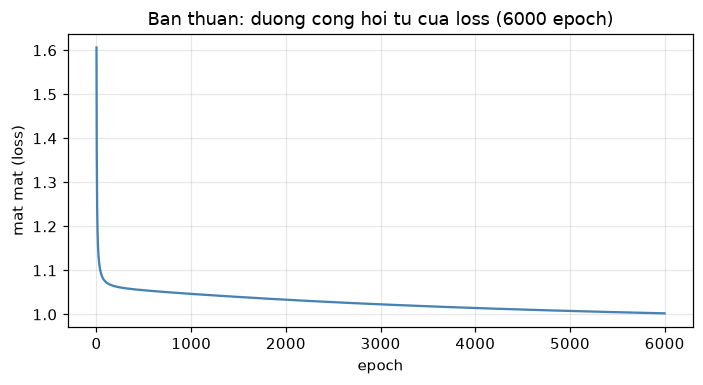

In [5]:
def train_softmax_pure(X, y, K, lr=0.5, epochs=6000, seed=0):
    """Softmax regression bang GD nguyen ban - chi dung NumPy."""
    rng = np.random.default_rng(seed)
    d = X.shape[1]
    W = rng.normal(size=(d, K)) * 0.01           # khoi tao nho
    b = np.zeros(K)
    Y = np.eye(K)[y]                              # one-hot
    history = []
    for _ in range(epochs):
        L, gW, gb = loss_and_grad(W, b, X, Y)
        history.append(L)
        W -= lr * gW
        b -= lr * gb
    return W, b, history

def predict(W, b, X):
    return softmax(X @ W + b).argmax(axis=1)

def accuracy(W, b, X, y):
    return (predict(W, b, X) == y).mean()

from sklearn.metrics import f1_score, classification_report

t0 = time.perf_counter()
W_p, b_p, hist = train_softmax_pure(Xtr_s, mtr, K=K, lr=0.5, epochs=6000)
t_pure = time.perf_counter() - t0
acc_tr_p = accuracy(W_p, b_p, Xtr_s, mtr)
acc_te_p = accuracy(W_p, b_p, Xte_s, mte)
pred_te_p = predict(W_p, b_p, Xte_s)
f1_te_p = f1_score(mte, pred_te_p, average="macro")
f1_perclass_p = f1_score(mte, pred_te_p, average=None)
print("BAN THUAN:  train acc = %.4f | test acc = %.4f | F1-macro = %.4f | loss = %.4f | thoi gian = %.2fs"
      % (acc_tr_p, acc_te_p, f1_te_p, hist[-1], t_pure))
print("\nBao cao phan loai chi tiet (tap test):")
print(classification_report(mte, pred_te_p, target_names=CLS_NAMES, digits=4))

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(hist, color="steelblue"); ax.set_xlabel("epoch"); ax.set_ylabel("mat mat (loss)")
ax.set_title("Ban thuan: duong cong hoi tu cua loss (6000 epoch)"); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

**Nhận xét về F1 từng lớp:** với dữ liệu lệch, kỳ vọng F1 của **Fair** và **Good** (lớp thiểu số, ~3% và ~9% dữ liệu) thấp hơn hẳn **Premium** và **Ideal** (lớp đa số). Biểu đồ dưới xác nhận điều này.

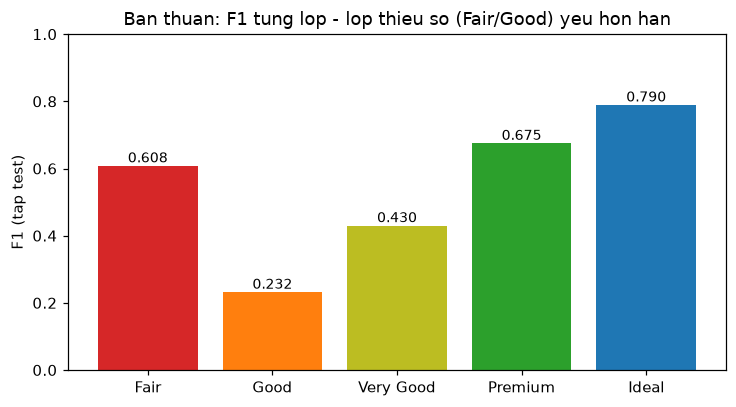

In [6]:
fig, ax = plt.subplots(figsize=(6.8, 3.8))
bars = ax.bar(CLS_NAMES, f1_perclass_p, color=colors5)
for b, v in zip(bars, f1_perclass_p):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, "%.3f" % v, ha="center", fontsize=9)
ax.set_ylabel("F1 (tap test)"); ax.set_ylim(0, 1.0)
ax.set_title("Ban thuan: F1 tung lop - lop thieu so (Fair/Good) yeu hon han")
fig.tight_layout(); plt.show()

## 4. Giai đoạn 3 — BẢN THƯ VIỆN (scikit-learn)

`LogisticRegression` của scikit-learn (từ bản ≥1.5) mặc định dùng **multinomial (softmax)** khi có hơn 2 lớp, solver **LBFGS** (bậc hai, xấp xỉ Hessian) — hội tụ sâu hơn GD nguyên bản trên bài toán lồi, và có sẵn **chính quy hoá L2** (bản thuần ở Mục 3 không có).

In [7]:
from sklearn.linear_model import LogisticRegression

t0 = time.perf_counter()
clf = LogisticRegression(max_iter=2000).fit(Xtr_s, mtr)
t_lib = time.perf_counter() - t0
acc_tr_l = clf.score(Xtr_s, mtr)
acc_te_l = clf.score(Xte_s, mte)
pred_te_l = clf.predict(Xte_s)
f1_te_l = f1_score(mte, pred_te_l, average="macro")
print("BAN LIB (sklearn, multinomial/LBFGS):  train acc = %.4f | test acc = %.4f | F1-macro = %.4f | thoi gian = %.4fs"
      % (acc_tr_l, acc_te_l, f1_te_l, t_lib))
print("\nBao cao phan loai chi tiet (tap test):")
print(classification_report(mte, pred_te_l, target_names=CLS_NAMES, digits=4))

BAN LIB (sklearn, multinomial/LBFGS):  train acc = 0.6556 | test acc = 0.6517 | F1-macro = 0.5492 | thoi gian = 1.2061s

Bao cao phan loai chi tiet (tap test):
              precision    recall  f1-score   support

        Fair     0.8205    0.4969    0.6190       322
        Good     0.5735    0.1194    0.1976       980
   Very Good     0.4827    0.4441    0.4626      2416
     Premium     0.6501    0.7159    0.6814      2756
       Ideal     0.7226    0.8596    0.7852      4310

    accuracy                         0.6517     10784
   macro avg     0.6499    0.5272    0.5492     10784
weighted avg     0.6397    0.6517    0.6280     10784



## 5. Giai đoạn 4 — BẢN FRAMEWORK (PyTorch) — cuối cùng

Cùng mô hình, cùng **learning rate và số epoch của bản thuần** (0.5, 6000) để so sánh công bằng: `nn.Linear(8,5)` chính là $z = W^\top x + b$; `CrossEntropyLoss` gộp log-softmax và entropy chéo (đã ổn định số bằng log-sum-exp), tối ưu bằng SGD toàn batch (full-batch) giống hệt bản thuần.

In [8]:
import torch
import torch.nn as nn

torch.manual_seed(0)
Xtr_t = torch.tensor(Xtr_s, dtype=torch.float64)
Xte_t = torch.tensor(Xte_s, dtype=torch.float64)
mtr_t = torch.tensor(mtr, dtype=torch.long)
mte_t = torch.tensor(mte, dtype=torch.long)

model = nn.Linear(8, K).double()
opt = torch.optim.SGD(model.parameters(), lr=0.5)
crit = nn.CrossEntropyLoss()

t0 = time.perf_counter()
for _ in range(6000):
    opt.zero_grad()
    loss = crit(model(Xtr_t), mtr_t)
    loss.backward()
    opt.step()
t_fw = time.perf_counter() - t0
with torch.no_grad():
    pred_tr_f = model(Xtr_t).argmax(1)
    pred_te_f = model(Xte_t).argmax(1)
    acc_tr_f = (pred_tr_f == mtr_t).float().mean().item()
    acc_te_f = (pred_te_f == mte_t).float().mean().item()
f1_te_f = f1_score(mte, pred_te_f.numpy(), average="macro")
print("BAN FW (PyTorch, SGD lr=0.5, 6000 epoch):   train acc = %.4f | test acc = %.4f | F1-macro = %.4f | loss = %.4f | thoi gian = %.2fs"
      % (acc_tr_f, acc_te_f, f1_te_f, loss.item(), t_fw))

BAN FW (PyTorch, SGD lr=0.5, 6000 epoch):   train acc = 0.6528 | test acc = 0.6499 | F1-macro = 0.5456 | loss = 1.0042 | thoi gian = 22.10s


## 6. So sánh ba giai đoạn cài đặt và kết luận

Cùng dữ liệu, cùng phân chia, cùng chuẩn hoá — so sánh accuracy, F1-macro và thời gian huấn luyện.

Phuong an                  | train acc | test acc  | F1-macro  | thoi gian(s)
------------------------------------------------------------------------------
Ban thuan (NumPy, GD)      | 0.6527    | 0.6504    | 0.5471    | 66.47   
Ban lib (sklearn, LBFGS)   | 0.6556    | 0.6517    | 0.5492    | 1.21    
Ban fw (PyTorch, SGD)      | 0.6528    | 0.6499    | 0.5456    | 22.10   


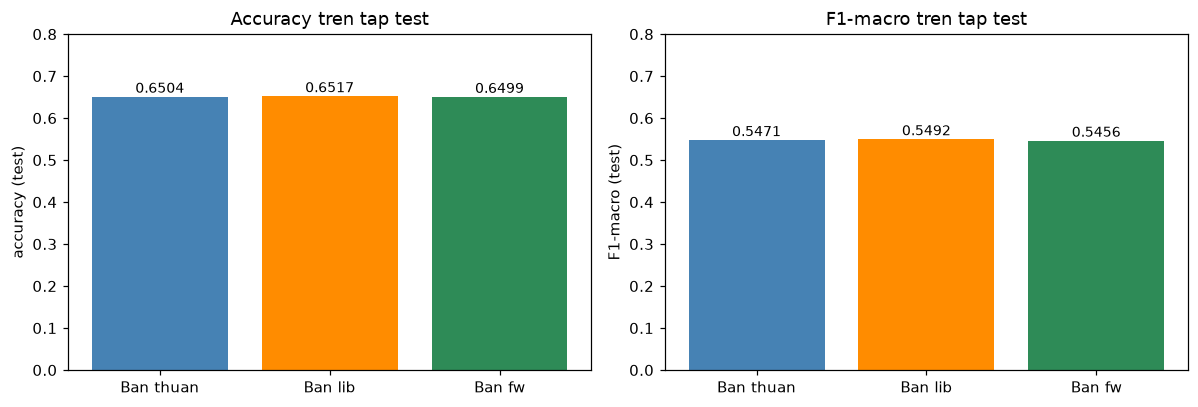

In [9]:
rows = [
    ("Ban thuan (NumPy, GD)",      "%.4f" % acc_tr_p, "%.4f" % acc_te_p, "%.4f" % f1_te_p, "%.2f" % t_pure),
    ("Ban lib (sklearn, LBFGS)",   "%.4f" % acc_tr_l, "%.4f" % acc_te_l, "%.4f" % f1_te_l, "%.2f" % t_lib),
    ("Ban fw (PyTorch, SGD)",      "%.4f" % acc_tr_f, "%.4f" % acc_te_f, "%.4f" % f1_te_f, "%.2f" % t_fw),
]
print("%-26s | %-9s | %-9s | %-9s | %-8s" % ("Phuong an", "train acc", "test acc", "F1-macro", "thoi gian(s)"))
print("-" * 78)
for r in rows:
    print("%-26s | %-9s | %-9s | %-9s | %-8s" % r)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
names = ["Ban thuan", "Ban lib", "Ban fw"]
accs = [acc_te_p, acc_te_l, acc_te_f]
f1s = [f1_te_p, f1_te_l, f1_te_f]
axes[0].bar(names, accs, color=["steelblue", "darkorange", "seagreen"])
axes[0].set_ylabel("accuracy (test)"); axes[0].set_ylim(0, 0.8)
axes[0].set_title("Accuracy tren tap test")
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, "%.4f" % v, ha="center", fontsize=9)
axes[1].bar(names, f1s, color=["steelblue", "darkorange", "seagreen"])
axes[1].set_ylabel("F1-macro (test)"); axes[1].set_ylim(0, 0.8)
axes[1].set_title("F1-macro tren tap test")
for i, v in enumerate(f1s):
    axes[1].text(i, v + 0.01, "%.4f" % v, ha="center", fontsize=9)
fig.tight_layout(); plt.show()

**Thảo luận trung thực về khoảng cách thuần vs lib/framework:**

- Cả 3 cách cho accuracy và F1-macro **rất gần nhau** (~0.65 accuracy, ~0.55 F1-macro) — bản thuần cài **đúng công thức toán**, khoảng cách nhỏ còn lại đến từ (i) bản lib dùng solver LBFGS bậc hai + có L2, hội tụ sâu hơn GD học suất cố định; (ii) bản thuần cần **6000 epoch** (gấp đôi bài Iris) do đa cộng tuyến vừa phải giữa `carat` và `x, y, z` làm bề mặt loss "thoải" theo một số hướng — GD học suất cố định đi chậm hơn theo các hướng đó.
- **Vì sao bài toán 5 lớp khó hơn hẳn bài nhị phân (Logistic, "Ideal vs không", ~0.79 accuracy):**
  1. **Ranh giới 5 chiều thay vì 1 chiều**: softmax phải học *4 siêu phẳng phân tách độc lập* (thực chất $K-1=4$ bậc tự do) thay vì 1 ranh giới nhị phân — không gian giả thuyết lớn hơn nhiều, dễ nhầm giữa các lớp liền kề.
  2. **Các mức chất lượng liền kề vật lý rất giống nhau**: Fair/Good/Very Good/Premium/Ideal là một **thang thứ bậc liên tục** về cách cắt (góc, tỷ lệ), không có ranh giới vật lý rõ như "Ideal hay không" — 2 viên kim cương ở Very Good và Premium có thể có `carat, depth, table, x, y, z` gần như trùng nhau, chỉ khác biệt ở tiêu chuẩn đánh giá tinh vi mà 8 đặc trưng hình học không nắm bắt hết.
  3. **Lớp thiểu số bị "kẹp" giữa 2 lớp lớn**: Fair (3% dữ liệu) và Good (9%) không chỉ ít mẫu để học mà còn **nằm giữa** Very Good/Premium/Ideal trong không gian đặc trưng (kim cương "cắt xấu" vẫn có thể có kích thước carat tương tự) → mô hình tuyến tính dễ "nuốt" các lớp này vào lớp lân cận đông hơn, thể hiện rõ ở F1 thấp của Fair/Good tại Mục 3.

- **Khi nào dùng cái nào?** Hiểu thuật toán → bản thuần (mọi dòng mã ánh xạ công thức, kiểm chứng được bằng sai phân hữu hạn). Triển khai thực tế → thư viện/framework (nhanh hơn, ổn định hơn, có chính quy hoá).
- **Chuẩn bị cho multi-task:** nhánh đầu ra 5 lớp `Wᵀx+b -> softmax -> CrossEntropyLoss` ở đây sẽ được ghép cùng nhánh hồi quy `price` và nhánh nhị phân `cut==Ideal` trên **một thân mạng chung** ở notebook multi-task — vì cả 3 đều dùng chung 8 đặc trưng, cùng phép chuẩn hoá, cùng train/test split.